
# <span style="color:rgb(213,80,0)">Battery impedance computation</span>

We compute the impedance of a lithium\-ion battery cell at different states of charge (SOC) using the Battmo framework. The impedance is computed using the ImpedanceSolver class, which takes into account the electrochemical properties of the battery cell as defined in a JSON file. The results are plotted in a Nyquist plot, showing the real and imaginary parts of the impedance.

## Battery input parameters

We load a JSON file containing the parameters of a lithium\-ion battery cell, and set up the model using the setupModelFromJson function. We also disable thermal effects and current collectors for this impedance computation.


In [1]:
filename = fullfile(fullfile('ParameterData'        , ...
                             'BatteryCellParameters', ...
                             'LithiumIonBatteryCell', ...
                             'lithium_ion_battery_nmc_graphite.json'));
jsonstruct = parseBattmoJson(filename);

jsonstruct.use_thermal                = false;
jsonstruct.include_current_collectors = false;

[model, inputparams, jsonstruct, gen] = setupModelFromJson(jsonstruct);

## Impedance computation

Plot settings



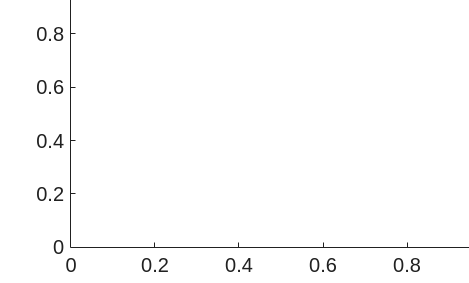

In [2]:
set(0, 'defaultlinelinewidth', 1);
set(0, 'defaultaxesfontsize', 15);

figure
hold on


We compute the impedance for different SOC values, and plot the results in a Nyquist plot. The impedance is normalized by the face area of the model and converted to Ωcm^2 for better visualization.



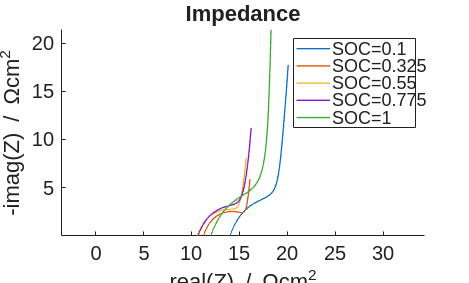

In [3]:
socs = linspace(0.1, 1, 5);

options = [];
options.stateInitialization.initializationSetup = 'soc';

for isoc = 1 : numel(socs)

    soc = socs(isoc);

    options.stateInitialization.soc = soc;
    impsolv = ImpedanceSolver(inputparams, options);

    omegas = linspace(-3, 6, 500);
    omegas = 10.^omegas;
    Z = impsolv.computeImpedance(omegas);

    Z = (Z*gen.faceArea)/((centi*meter)^2);

    legtxt = sprintf('SOC=%g', soc);
    plot(real(Z), -imag(Z), 'displayname', legtxt);
    xlabel('real(Z) / Ωcm^2')
    ylabel('-imag(Z) / Ωcm^2')

end

legend show
title('Impedance')
axis equal